In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.feature_extraction import FeatureHasher
import time
 
pd.set_option('display.max_columns', 100)
TARGET_COLUMN = 'SalePrice'
ID_COLUMN = 'Id'
RANDOM_STATE = 42

In [3]:
train_df = pd.read_csv('train.csv')
print(f'train_df shape: {train_df.shape}')
train_df.head()

train_df shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
def get_categorical_columns(df, exclude=None):
    exclude = exclude or []
    return [col for col in df.columns
            if pd.api.types.is_string_dtype(df[col]) and col not in exclude]
 
categorical_columns = get_categorical_columns(train_df, exclude=[ID_COLUMN, TARGET_COLUMN])
print(f'Found {len(categorical_columns)} categorical columns')

Found 27 categorical columns


In [4]:

NA_MEANS_NONE_COLUMNS = [
    'Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType',
    'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature'
]

def fill_structural_missing(df, columns, fill_value='None'):
  
    df = df.copy()
    present_columns = [c for c in columns if c in df.columns]
    df[present_columns] = df[present_columns].fillna(fill_value)
    return df

def fill_remaining_categorical(df, columns):

    df = df.copy()
    for col in columns:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])
    return df

train_clean = fill_structural_missing(train_df, NA_MEANS_NONE_COLUMNS)
train_clean = fill_remaining_categorical(train_clean, categorical_columns)

test_clean = fill_structural_missing(test_df, NA_MEANS_NONE_COLUMNS)
test_clean = fill_remaining_categorical(test_clean, categorical_columns)

print('Remaining missing values in categorical columns (train):',
      train_clean[categorical_columns].isnull().sum().sum())

Remaining missing values in categorical columns (train): 0


In [5]:
NA_MEANS_NONE_COLUMNS = [
    'Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType',
    'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature'
]
 
def fill_structural_missing(df, columns, fill_value='None'):
    df = df.copy()
    present_columns = [c for c in columns if c in df.columns]
    df[present_columns] = df[present_columns].fillna(fill_value)
    return df
 
def fill_remaining_categorical(df, columns):
    df = df.copy()
    for col in columns:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])
    return df
 
train_clean = fill_structural_missing(train_df, NA_MEANS_NONE_COLUMNS)
train_clean = fill_remaining_categorical(train_clean, categorical_columns)
print('Remaining missing values in categorical columns:',
      train_clean[categorical_columns].isnull().sum().sum())

Remaining missing values in categorical columns: 0


In [6]:
def add_engineered_features(df):
    df = df.copy()
    area_cols = ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']
    if all(c in df.columns for c in area_cols):
        df['TotalSF'] = df[area_cols].sum(axis=1)
    if {'YrSold', 'YearBuilt'}.issubset(df.columns):
        df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    if {'YrSold', 'YearRemodAdd'}.issubset(df.columns):
        df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    if {'YearBuilt', 'YearRemodAdd'}.issubset(df.columns):
        df['WasRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)
    bath_cols = ['FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath']
    if all(c in df.columns for c in bath_cols):
        df['TotalBath'] = (df['FullBath'] + df['BsmtFullBath']
                            + 0.5 * (df['HalfBath'] + df['BsmtHalfBath']))
    flag_map = {'HasGarage': 'GarageArea', 'HasPool': 'PoolArea',
                'HasFireplace': 'Fireplaces', 'Has2ndFlr': '2ndFlrSF', 'HasBsmt': 'TotalBsmtSF'}
    for flag_name, source_col in flag_map.items():
        if source_col in df.columns:
            df[flag_name] = (df[source_col] > 0).astype(int)
    if {'OverallQual', 'GrLivArea'}.issubset(df.columns):
        df['QualxArea'] = df['OverallQual'] * df['GrLivArea']
    return df
 
def remove_known_outliers(df, target_col):
    if 'GrLivArea' in df.columns and target_col in df.columns:
        mask = ~((df['GrLivArea'] > 4000) & (df[target_col] < 300000))
        removed = (~mask).sum()
        print(f'Removed {removed} outlier row(s)')
        return df.loc[mask].reset_index(drop=True)
    return df
 
train_fe = add_engineered_features(train_clean)
train_fe = remove_known_outliers(train_fe, TARGET_COLUMN)
print(f'Rows after outlier removal: {len(train_fe)} (was {len(train_clean)})')

Removed 2 outlier row(s)
Rows after outlier removal: 1458 (was 1460)


In [7]:
QUALITY_SCALE = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
QUALITY_SCALE_COLUMNS = ['ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual',
                          'FireplaceQu', 'GarageQual', 'GarageCond']
QUALITY_SCALE_WITH_NONE = ['BsmtQual', 'BsmtCond', 'PoolQC']
 
def build_ordinal_encoder(base_scale, has_none=False):
    order = (['None'] + base_scale) if has_none else base_scale
    return OrdinalEncoder(categories=[order], handle_unknown='use_encoded_value', unknown_value=-1)
 
def fit_frequency_map(series):
    return series.value_counts(normalize=True).to_dict()
 
def apply_frequency_map(series, frequency_map, default=0.0):
    return series.map(frequency_map).fillna(default)
 
def fit_target_map(series, target):
    return target.groupby(series).mean().to_dict()
 
def split_columns_by_cardinality(columns, cardinality, low_cardinality_max):
    low = [c for c in columns if cardinality[c] <= low_cardinality_max]
    high = [c for c in columns if cardinality[c] > low_cardinality_max]
    return low, high
 
LOW_CARDINALITY_MAX = 10
cardinality = train_fe[categorical_columns].nunique()
ordinal_quality_columns = QUALITY_SCALE_COLUMNS + QUALITY_SCALE_WITH_NONE
nominal_columns = [c for c in categorical_columns if c not in ordinal_quality_columns]
low_card_nominal, high_card_nominal = split_columns_by_cardinality(
    nominal_columns, cardinality, LOW_CARDINALITY_MAX
)
print(f'Ordinal (quality-scale) columns : {len(ordinal_quality_columns)}')
print(f'Low-cardinality nominal columns : {len(low_card_nominal)}')
print(f'High-cardinality nominal columns: {len(high_card_nominal)} -> {high_card_nominal}')

Ordinal (quality-scale) columns : 10
Low-cardinality nominal columns : 20
High-cardinality nominal columns: 3 -> ['Neighborhood', 'Exterior1st', 'Exterior2nd']


In [9]:
def apply_pathway_A(df):
    df = df.copy()
    for col in QUALITY_SCALE_COLUMNS:
        df[col] = build_ordinal_encoder(QUALITY_SCALE, has_none=False).fit_transform(df[[col]])
    for col in QUALITY_SCALE_WITH_NONE:
        df[col] = build_ordinal_encoder(QUALITY_SCALE, has_none=True).fit_transform(df[[col]])
    df = pd.get_dummies(df, columns=low_card_nominal, drop_first=False)
    for col in high_card_nominal:
        df[col] = apply_frequency_map(df[col], fit_frequency_map(df[col]))
    return df

def apply_pathway_B(df):
    df = df.copy()
    for col in categorical_columns:
        df[col] = LabelEncoder().fit_transform(df[col])
    return df

def apply_pathway_C(df):
    return pd.get_dummies(df, columns=categorical_columns, drop_first=False)

def apply_pathway_D_hashing(df, n_features=128):
    df = df.copy()
    records = df[categorical_columns].astype(str).to_dict(orient='records')
    hasher = FeatureHasher(n_features=n_features, input_type='dict')
    hashed = hasher.transform(records).toarray()
    hashed_df = pd.DataFrame(hashed, columns=[f'hash_{i}' for i in range(n_features)], index=df.index)
    non_cat = df.drop(columns=categorical_columns)
    return pd.concat([non_cat, hashed_df], axis=1)

def apply_pathway_E_frequency_all(df):
    df = df.copy()
    for col in categorical_columns:
        df[col] = apply_frequency_map(df[col], fit_frequency_map(df[col]))
    return df

def apply_pathway_F_cyclic(df):
    df = df.copy()
    if 'MoSold' in df.columns:
        df['MoSold_sin'] = np.sin(2 * np.pi * df['MoSold'] / 12)
        df['MoSold_cos'] = np.cos(2 * np.pi * df['MoSold'] / 12)
        df = df.drop(columns=['MoSold'])
    remaining_cat = [c for c in categorical_columns if c in df.columns]
    return pd.get_dummies(df, columns=remaining_cat, drop_first=False)

def apply_pathway_G_target_leaky(df, target_col):
    df = df.copy()
    for col in categorical_columns:
        df[col] = df[col].map(fit_target_map(df[col], df[target_col]))
    return df

def apply_pathway_H_kfold_target(df, target_col, n_splits=5, random_state=RANDOM_STATE):
    df = df.copy()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    global_mean = df[target_col].mean()
    for col in categorical_columns:
        encoded = pd.Series(index=df.index, dtype=float)
        for tr_idx, val_idx in kf.split(df):
            fold_map = fit_target_map(df.iloc[tr_idx][col], df.iloc[tr_idx][target_col])
            encoded.iloc[val_idx] = df.iloc[val_idx][col].map(fold_map).values
        df[col] = encoded.fillna(global_mean)
    return df

In [10]:
all_pathways = {
    'A: mixed': apply_pathway_A(train_fe),
    'B: label-encode all': apply_pathway_B(train_fe),
    'C: one-hot all': apply_pathway_C(train_fe),
    'D: feature hashing': apply_pathway_D_hashing(train_fe),
    'E: frequency (all cols)': apply_pathway_E_frequency_all(train_fe),
    'F: cyclic + one-hot': apply_pathway_F_cyclic(train_fe),
    'G: target encoding (leaky)': apply_pathway_G_target_leaky(train_fe, TARGET_COLUMN),
    'H: k-fold target encoding': apply_pathway_H_kfold_target(train_fe, TARGET_COLUMN),
}
 
pd.DataFrame({
    'pathway': list(all_pathways.keys()),
    'resulting_columns': [df.shape[1] for df in all_pathways.values()],
})

,pathway,resulting_columns
0,A: mixed,179
1,B: label-encode all,92
2,C: one-hot all,246
3,D: feature hashing,193
4,E: frequency (all cols),92
5,F: cyclic + one-hot,247
6,G: target encoding (leaky),92
7,H: k-fold target encoding,92


In [11]:
def prepare_features(df, target_column, id_column):
    X = df.drop(columns=[target_column, id_column], errors='ignore')
    y = df[target_column]
    numeric_columns = X.select_dtypes(include=[np.number]).columns
    if not numeric_columns.empty:
        X[numeric_columns] = SimpleImputer(strategy='median').fit_transform(X[numeric_columns])
    return X[numeric_columns], y
 
def evaluate_pathway(df, target_column, id_column, model, cv_folds=5, random_state=RANDOM_STATE):
    X, y = prepare_features(df, target_column, id_column)
    y_log = np.log1p(y)
    cv = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    scores = cross_val_score(model, X, y_log, cv=cv, scoring='neg_root_mean_squared_error')
    return -scores.mean()
 
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}
 

In [12]:
results = []
t0 = time.time()
for pathway_name, encoded_df in all_pathways.items():
    for model_name, model in models.items():
        rmse = evaluate_pathway(encoded_df, TARGET_COLUMN, ID_COLUMN, model)
        results.append({
            'pathway': pathway_name,
            'model': model_name,
            'cv_rmse_log_saleprice': round(rmse, 4),
        })
        print(f'{pathway_name:30s} {model_name:20s} RMSE={rmse:.4f}')
print(f'\nTotal time: {time.time()-t0:.1f}s')

A: mixed                       LinearRegression     RMSE=0.1658
A: mixed                       RandomForest         RMSE=0.1354
A: mixed                       HistGradientBoosting RMSE=0.1287
B: label-encode all            LinearRegression     RMSE=0.1227
B: label-encode all            RandomForest         RMSE=0.1324
B: label-encode all            HistGradientBoosting RMSE=0.1254
C: one-hot all                 LinearRegression     RMSE=0.1283
C: one-hot all                 RandomForest         RMSE=0.1375
C: one-hot all                 HistGradientBoosting RMSE=0.1325
D: feature hashing             LinearRegression     RMSE=0.1202
D: feature hashing             RandomForest         RMSE=0.1340
D: feature hashing             HistGradientBoosting RMSE=0.1272
E: frequency (all cols)        LinearRegression     RMSE=0.1235
E: frequency (all cols)        RandomForest         RMSE=0.1329
E: frequency (all cols)        HistGradientBoosting RMSE=0.1254
F: cyclic + one-hot            LinearReg

In [13]:
results_df = pd.DataFrame(results).sort_values('cv_rmse_log_saleprice').reset_index(drop=True)
results_df

,pathway,model,cv_rmse_log_saleprice
0,G: target encoding (leaky),LinearRegression,0.1177
1,H: k-fold target encoding,LinearRegression,0.1182
2,D: feature hashing,LinearRegression,0.1202
3,B: label-encode all,LinearRegression,0.1227
4,E: frequency (all cols),LinearRegression,0.1235
5,G: target encoding (leaky),HistGradientBoosting,0.1243
6,E: frequency (all cols),HistGradientBoosting,0.1254
7,B: label-encode all,HistGradientBoosting,0.1254
8,H: k-fold target encoding,HistGradientBoosting,0.1269
9,D: feature hashing,HistGradientBoosting,0.1272


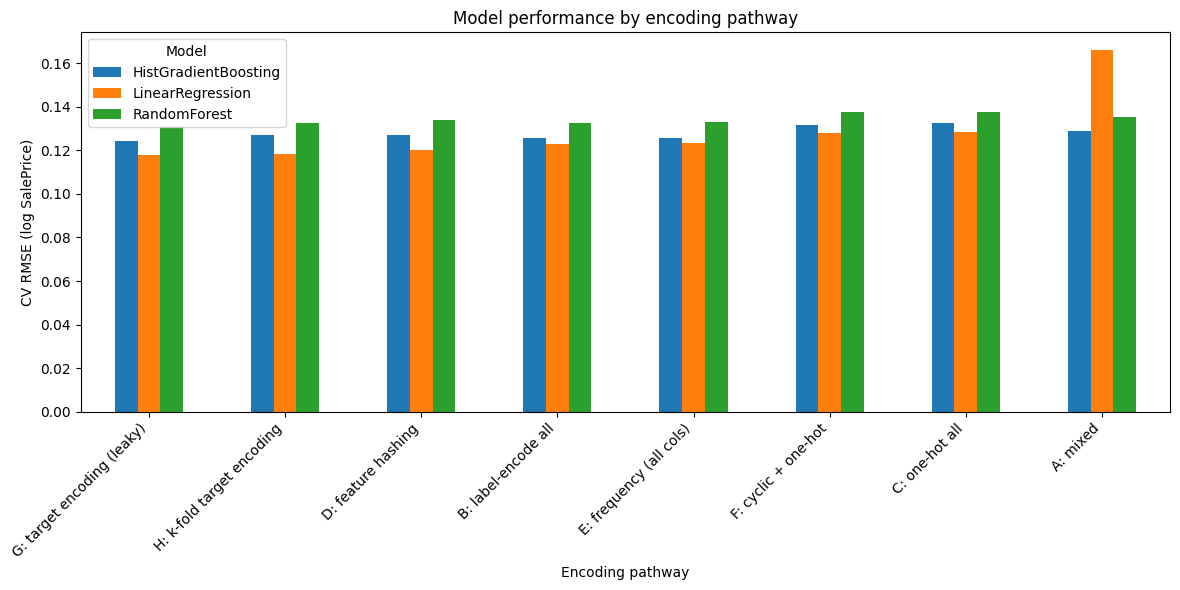

In [16]:
import matplotlib.pyplot as plt

pivot = results_df.pivot(index='pathway', columns='model', values='cv_rmse_log_saleprice')
pivot = pivot.reindex(results_df.groupby('pathway')['cv_rmse_log_saleprice'].min().sort_values().index)

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', ax=ax)
ax.set_ylabel('CV RMSE (log SalePrice)')
ax.set_xlabel('Encoding pathway')
ax.set_title('Model performance by encoding pathway')
ax.legend(title='Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
results_df.to_csv('engineered_all_encodings_results.csv', index=False)

In [17]:
test_df = pd.read_csv('test.csv')

In [18]:
train_modes = {col: train_df[col].mode()[0] for col in categorical_columns
               if train_df[col].isnull().any()}
 
test_clean = fill_structural_missing(test_df, NA_MEANS_NONE_COLUMNS)
test_clean = fill_remaining_categorical(test_clean, categorical_columns)  
test_fe = add_engineered_features(test_clean)

In [19]:
global_mean = train_fe[TARGET_COLUMN].mean()
target_maps = {}
train_final = train_fe.copy()
for col in categorical_columns:
    target_maps[col] = fit_target_map(train_final[col], train_final[TARGET_COLUMN])
    train_final[col] = train_final[col].map(target_maps[col])
 
test_final = test_fe.copy()
for col in categorical_columns:
    test_final[col] = test_final[col].map(target_maps[col]).fillna(global_mean)

In [21]:
X_train, _ = prepare_features(train_final, TARGET_COLUMN, ID_COLUMN)
y_train_log = np.log1p(train_final[TARGET_COLUMN])

X_test = test_final.drop(columns=[ID_COLUMN], errors='ignore')
numeric_columns = X_test.select_dtypes(include=[np.number]).columns
X_test = X_test[numeric_columns]
X_test = X_test.reindex(columns=X_train.columns)

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

In [22]:
from sklearn.linear_model import LinearRegression
 
model = LinearRegression()
model.fit(X_train_imputed, y_train_log)
 
pred_log = model.predict(X_test_imputed)
predicted_prices = np.expm1(pred_log)

In [23]:
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'PredictedSalePrice': predicted_prices.round(2)
})
 
print(submission.head(20).to_string(index=False))
print(f'\n...{len(submission)} total predictions')
print(f'\nPrediction range: ${submission["PredictedSalePrice"].min():,.0f} - ${submission["PredictedSalePrice"].max():,.0f}')
print(f'Mean predicted price: ${submission["PredictedSalePrice"].mean():,.0f}')
 
submission.to_csv('predicted_house_prices.csv', index=False)
submission

  Id  PredictedSalePrice
1461           111503.59
1462           153657.65
1463           171641.11
1464           195553.03
1465           201745.35
1466           166765.45
1467           184885.48
1468           157906.58
1469           189797.95
1470           117221.42
1471           177916.39
1472            99204.99
1473            94754.30
1474           152061.25
1475           122329.47
1476           355721.70
1477           253434.01
1478           288603.75
1479           270307.28
1480           512430.90

...1459 total predictions

Prediction range: $50,363 - $1,449,361
Mean predicted price: $178,585


,Id,PredictedSalePrice
0,1461,111503.59
1,1462,153657.65
2,1463,171641.11
3,1464,195553.03
4,1465,201745.35
...,...,...
1454,2915,89772.54
1455,2916,89242.81
1456,2917,182089.82
1457,2918,118092.65


In [24]:
submission.to_csv('predicted_house_prices.csv', index=False)